In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pandas.plotting import autocorrelation_plot

In [2]:
project_root = Path.cwd().parent  # Go up one level from /notebooks/ to the project root
data_path = project_root / "Data" / "Raw Data" / "AirQualityUCI.xlsx"

# --- Load the Dataset ---
df = pd.read_excel(data_path)

# --- Preview the Data ---
df.head()

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


In [3]:
# Shape and basic info
print(df.shape)
df.info()

# Summary statistics
df.describe(include='all')
# Replace -200 with NaN in the entire DataFrame
df.replace(-200, np.nan, inplace=True)

# Now check again
df.isnull().sum()

(9357, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9357 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Date           9357 non-null   datetime64[ns]
 1   Time           9357 non-null   object        
 2   CO(GT)         9357 non-null   float64       
 3   PT08.S1(CO)    9357 non-null   float64       
 4   NMHC(GT)       9357 non-null   int64         
 5   C6H6(GT)       9357 non-null   float64       
 6   PT08.S2(NMHC)  9357 non-null   float64       
 7   NOx(GT)        9357 non-null   float64       
 8   PT08.S3(NOx)   9357 non-null   float64       
 9   NO2(GT)        9357 non-null   float64       
 10  PT08.S4(NO2)   9357 non-null   float64       
 11  PT08.S5(O3)    9357 non-null   float64       
 12  T              9357 non-null   float64       
 13  RH             9357 non-null   float64       
 14  AH             9357 non-null   float64       
dtypes: datetim

Date                0
Time                0
CO(GT)           1683
PT08.S1(CO)       366
NMHC(GT)         8443
C6H6(GT)          366
PT08.S2(NMHC)     366
NOx(GT)          1639
PT08.S3(NOx)      366
NO2(GT)          1642
PT08.S4(NO2)      366
PT08.S5(O3)       366
T                 366
RH                366
AH                366
dtype: int64

In [4]:
# Drop duplicate rows first
df.drop_duplicates(inplace=True)

# If you have a time column (e.g., 'Date' or 'DateTime'), you can use time-based interpolation
# But first ensure it's a proper datetime index:
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Then interpolate respecting time gaps:
df.interpolate(method='time', inplace=True)

# Optional: Check if any NaNs remain
print(df.isnull().sum())

Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64


C:\Users\afons\AppData\Local\Temp\ipykernel_19624\3766811820.py:10: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df.interpolate(method='time', inplace=True)


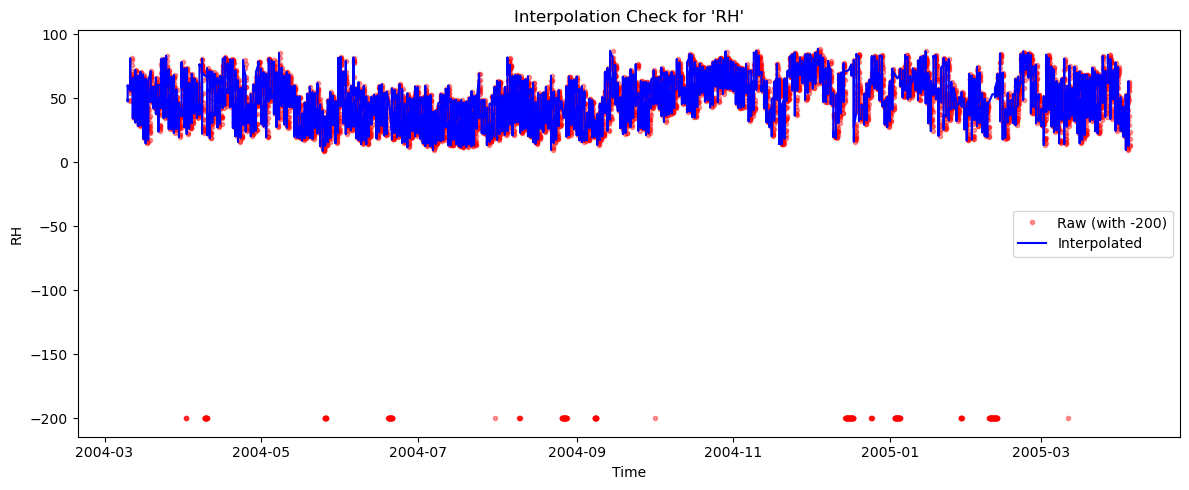

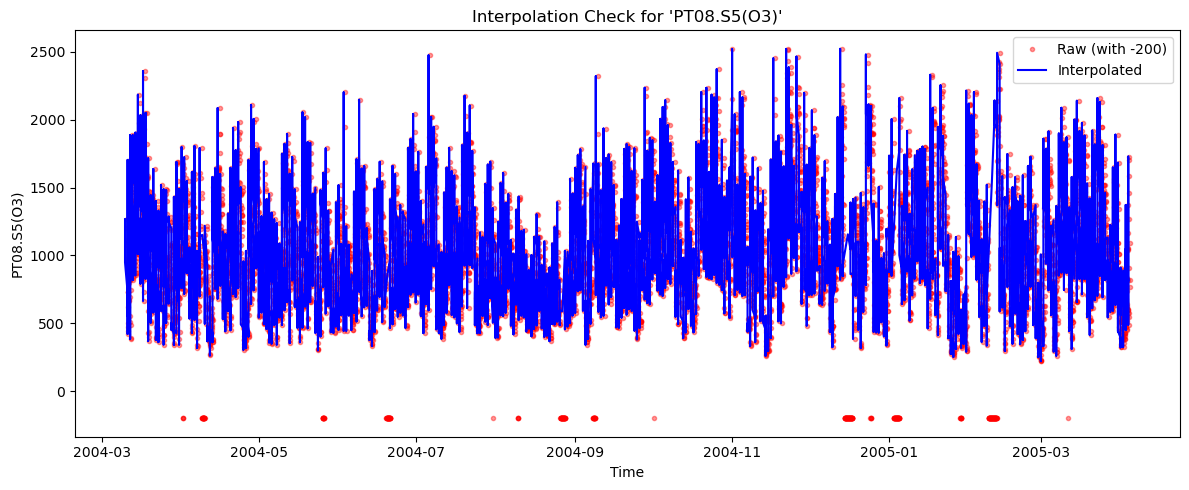

In [5]:
# Keep a copy of the raw (with -200 intact)
raw_df = pd.read_excel(data_path)
raw_df['DateTime'] = pd.to_datetime(raw_df['Date'].astype(str) + ' ' + raw_df['Time'].astype(str))
raw_df.set_index('DateTime', inplace=True)

# --- Choose columns to visualize ---
numeric_cols = df.select_dtypes(include=[np.number]).columns

np.random.seed(42)
cols_to_plot = np.random.choice(numeric_cols, size=min(2, len(numeric_cols)), replace=False)
# Example to manually pick: cols_to_plot = ['CO(GT)', 'NO2(GT)']

# --- Plot raw vs interpolated ---
for col in cols_to_plot:
    plt.figure(figsize=(12, 5))
    
    # Raw with -200 values
    plt.plot(raw_df.index, raw_df[col], 'r.', alpha=0.4, label='Raw (with -200)')
    
    # Interpolated data
    plt.plot(df.index, df[col], 'b-', linewidth=1.5, label='Interpolated')
    
    plt.title(f"Interpolation Check for '{col}'")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()

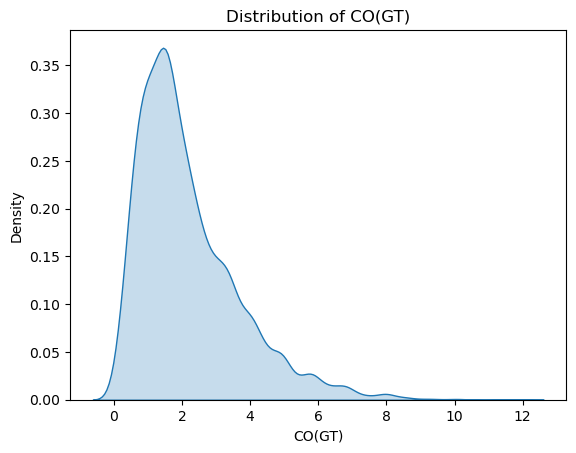

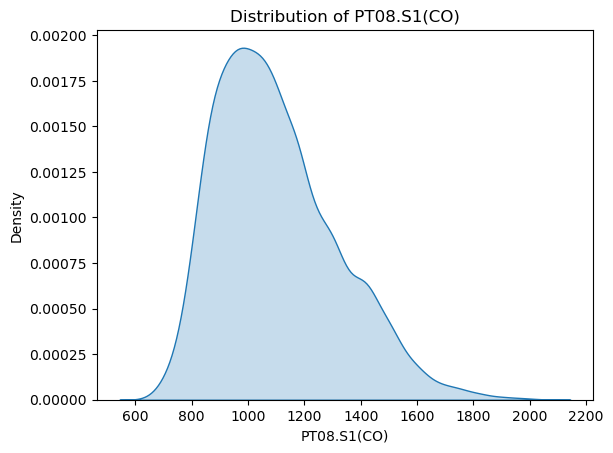

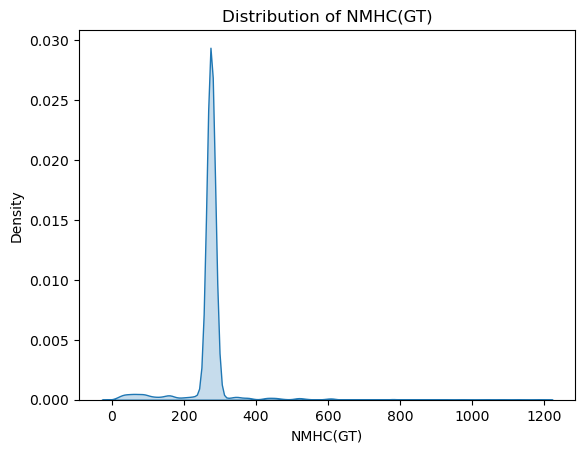

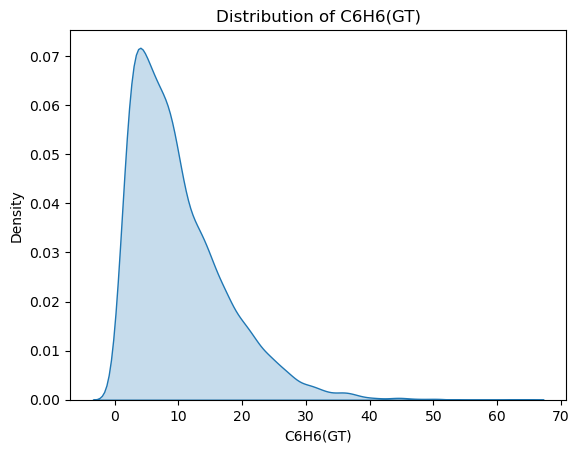

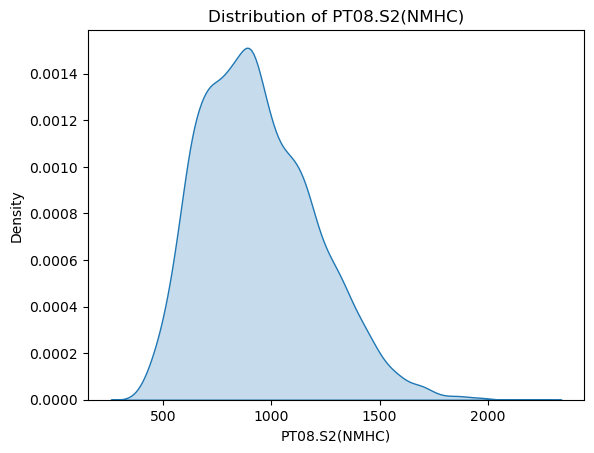

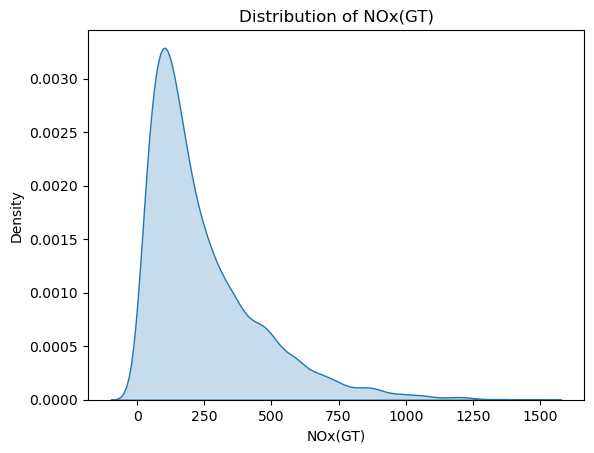

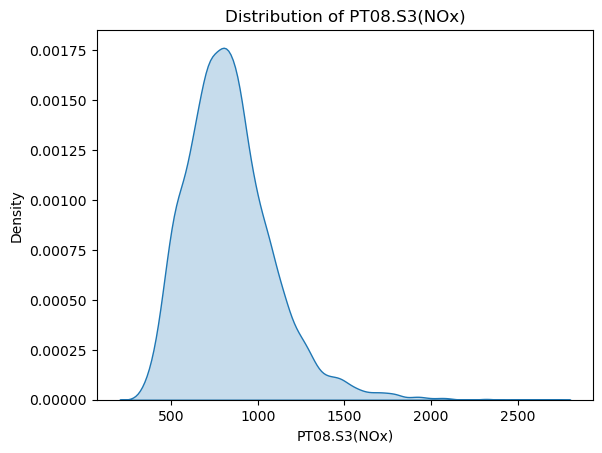

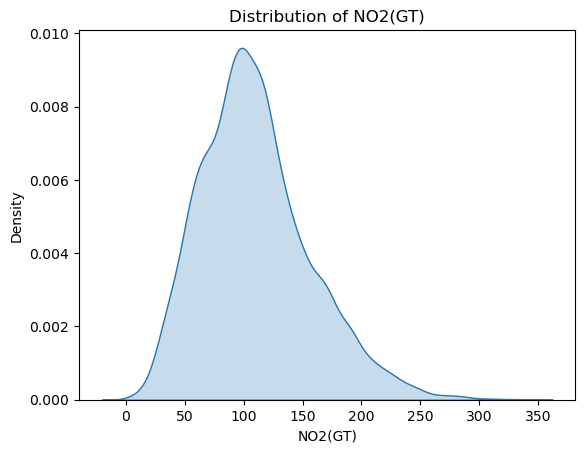

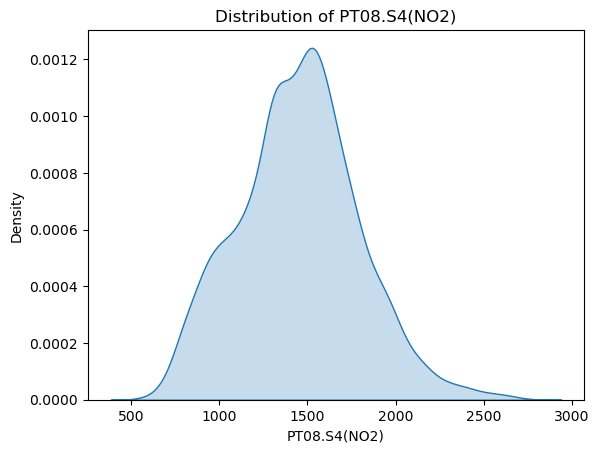

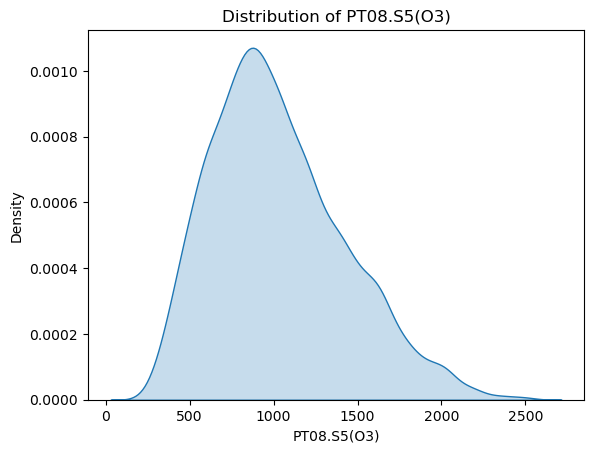

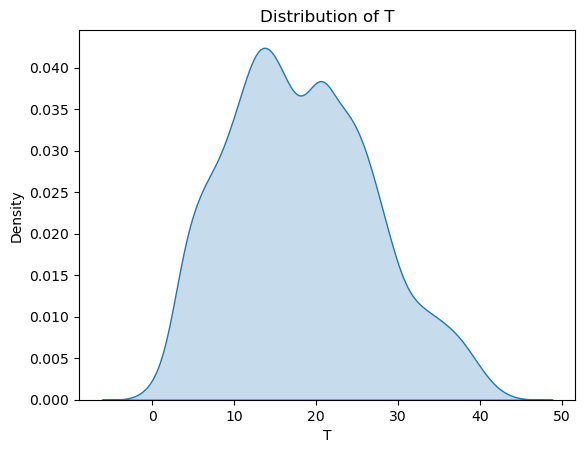

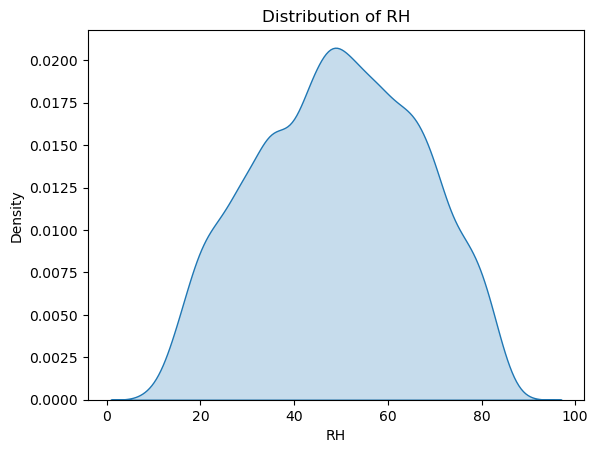

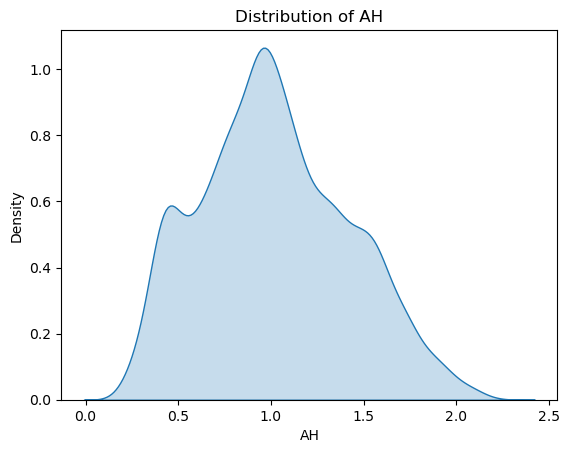

In [6]:
for col in numeric_cols:
    sns.kdeplot(df[col], fill=True)
    plt.title(f"Distribution of {col}")
    plt.show()

C:\Users\afons\AppData\Local\Temp\ipykernel_19624\3154662214.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  numeric_df.resample('M').mean().plot(figsize=(12, 6), title="Monthly Averages")


<Axes: title={'center': 'Monthly Averages'}, xlabel='Date'>

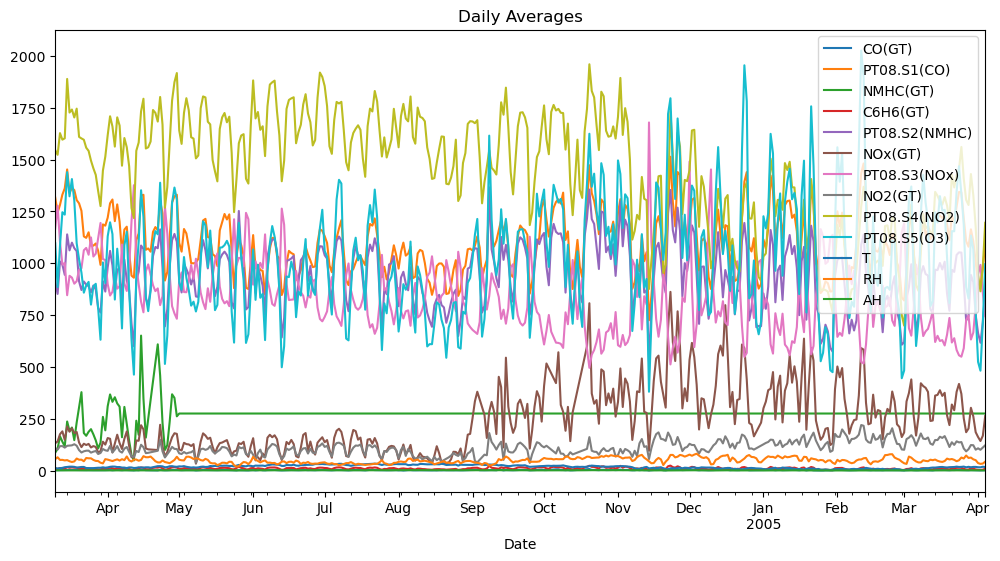

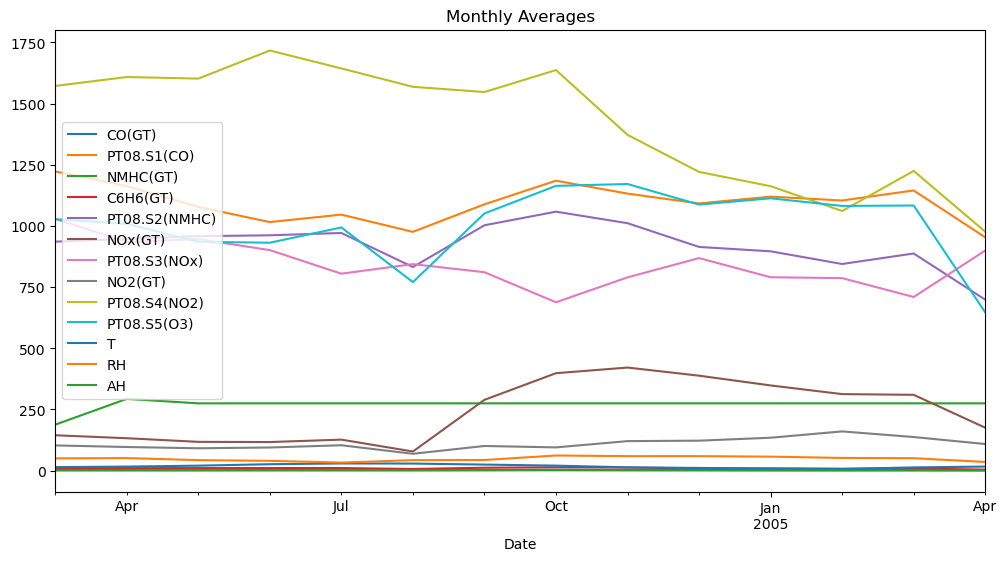

In [7]:
# Select only numeric columns for resampling
numeric_df = df.select_dtypes(include=[np.number])

# Daily averages
numeric_df.resample('D').mean().plot(figsize=(12, 6), title="Daily Averages")

# Monthly averages
numeric_df.resample('M').mean().plot(figsize=(12, 6), title="Monthly Averages")

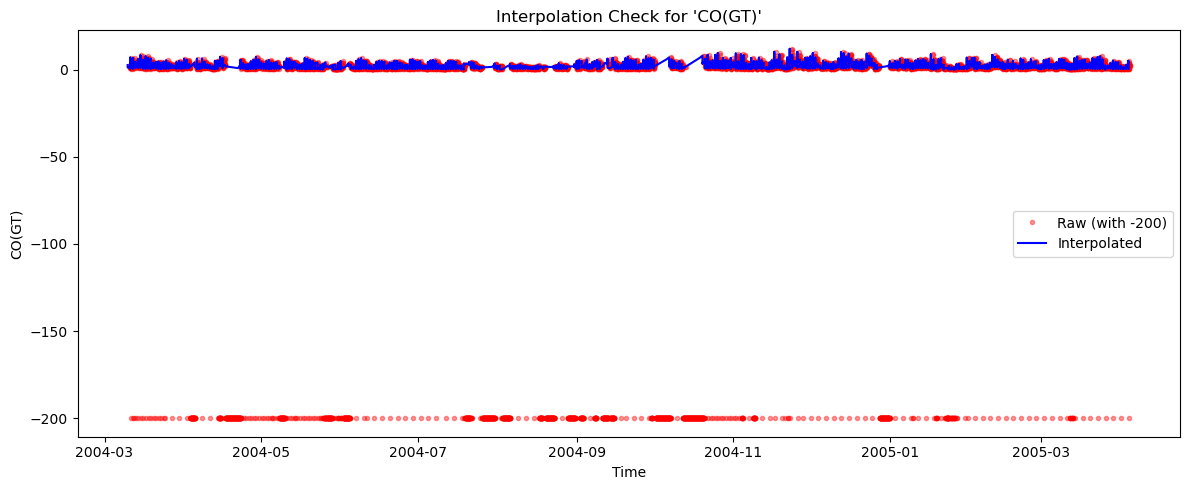

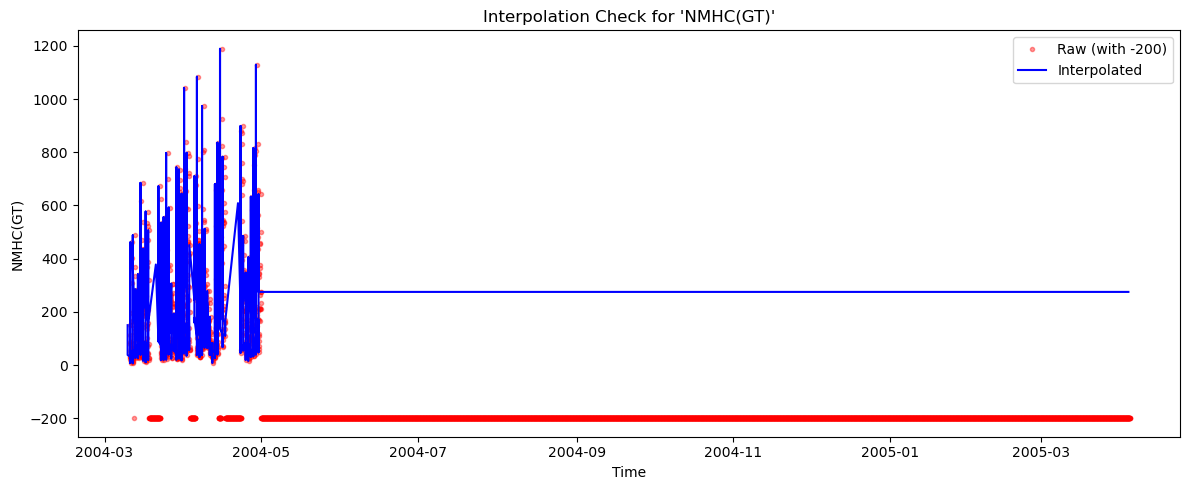

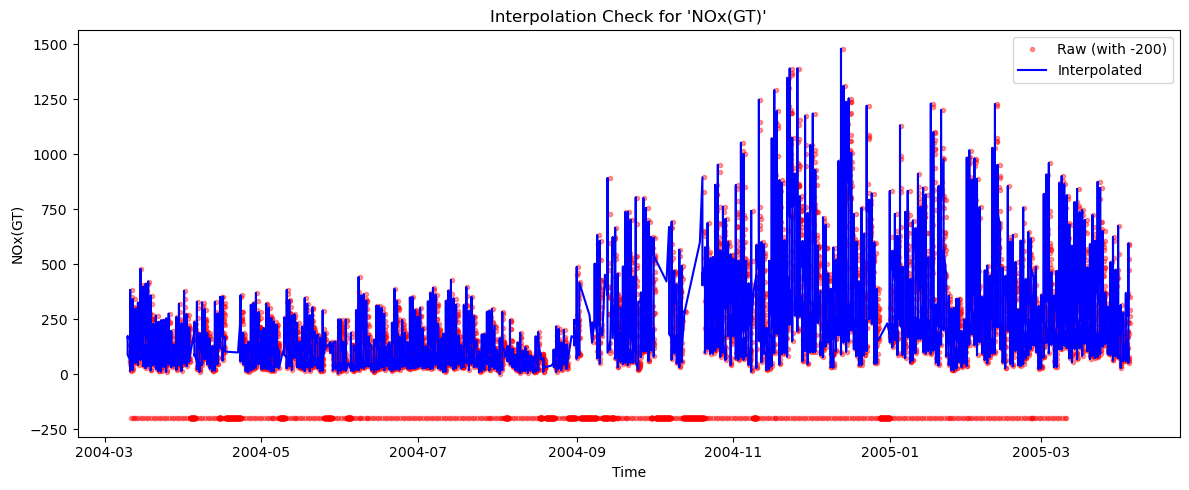

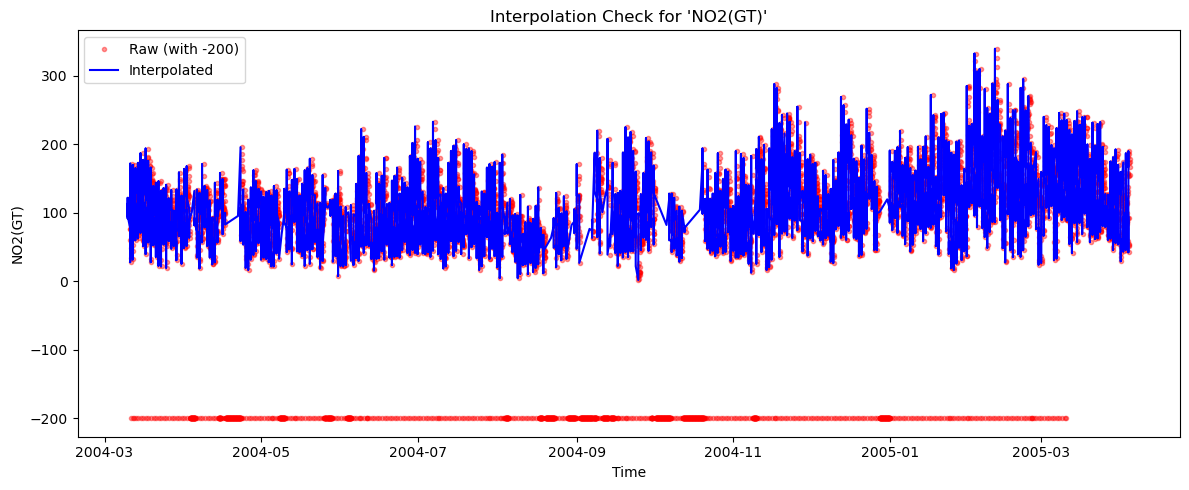

In [8]:
cols = ['CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)']

for col in cols:
    plt.figure(figsize=(12, 5))
    
    # Plot raw data (with -200 placeholders)
    plt.plot(raw_df.index, raw_df[col], 'r.', alpha=0.4, label='Raw (with -200)')
    
    # Plot cleaned/interpolated data
    plt.plot(df.index, df[col], 'b-', linewidth=1.5, label='Interpolated')
    
    plt.title(f"Interpolation Check for '{col}'")
    plt.xlabel("Time")
    plt.ylabel(col)
    plt.legend()
    plt.tight_layout()
    plt.show()


From the graphs above, we can clearly see that when at least 15% of the data is missing, the interpolation artifacts become noticeable.
In these cases, the interpolated segments introduce artificially smooth or constant patterns that do not represent actual sensor readings.

Keeping such features would risk introducing false patterns into the model, leading it to learn relationships that are not real.
Therefore, it is safer to drop these features entirely to preserve the integrity and reliability of the training data.

In [9]:
df = df.drop(columns=['CO(GT)', 'NMHC(GT)', 'NOx(GT)', 'NO2(GT)'])

In [10]:
# Define save location
processed_path = project_root / "Data" / "Processed Data"
processed_path.mkdir(parents=True, exist_ok=True)  # create folder if it doesn't exist

df.to_csv(processed_path / "AirQualityUCI_cleaned.csv", index=True)

pd.read_csv(processed_path / "AirQualityUCI_cleaned.csv").head()

File saved at: C:\Users\afons\OneDrive\Ambiente de Trabalho\Faculdade\Mestrado\2º Ano\1º Semestre\IntSis\Intelligent-Systems-Project\Project\Data\Processed Data


,Date,Time,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),PT08.S3(NOx),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,1360.00,11.881723,1045.50,1056.25,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,1292.25,9.397165,954.75,1173.75,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,1402.00,8.997817,939.25,1140.00,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,1375.50,9.228796,948.25,1092.00,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1272.25,6.518224,835.50,1205.00,1490.00,1110.00,11.15,59.575001,0.788794
